In [ ]:
import pandas as pd

url = "https://drive.google.com/uc?id=1quJH3KqmUd7ZBVaU4f4GtgoX0NWtAda8"
df = pd.read_csv(url)
X=df.drop(columns="condition")
y=df.condition
y.describe()

count    297.000000
mean       0.461279
std        0.499340
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: condition, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=4,
    random_state=42
)

rf.fit(X_train, y_train)
rf_train_score = rf.score(X_train, y_train) 
rf_test_score = rf.score(X_test, y_test)
print(f'rf_train_score: {rf_train_score} \nrf_test_score: {rf_test_score}')

rf_train_score: 0.9178743961352657 
rf_test_score: 0.7666666666666667


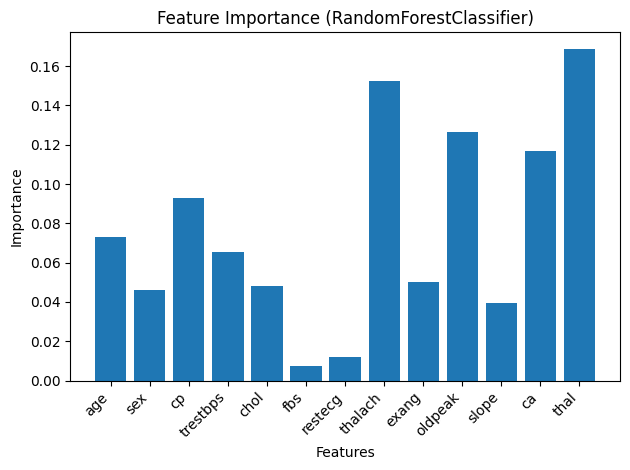

In [17]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X.columns

plt.figure()
plt.bar(range(len(importances)), importances)
plt.xticks(
    range(len(importances)),
    feature_names,
    rotation=45,
    ha='right'
)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (RandomForestClassifier)")
plt.tight_layout()
plt.show()

الف) Bootstrap Sampling

هر درخت فقط بخشی از داده‌ها را می‌بیند.

بعضی نمونه‌ها اصلاً در آموزش یک درخت نیستند.

ب) Random Feature Selection

در هر split فقط چند feature تصادفی بررسی می‌شوند. حتی اگر یک feature خیلی قوی باشد، همه‌ی درخت‌ها به آن تکیه نمی‌کنند.

➡️ نتیجه:
درخت‌ها decorrelated می‌شوند (همبستگی کمتر).

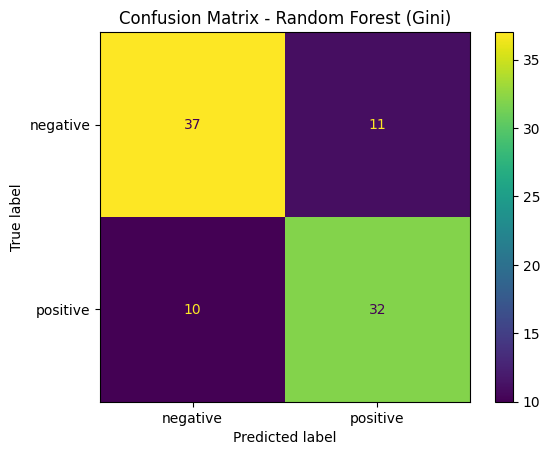

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["negative","positive"])
disp.plot()

plt.title("Confusion Matrix - Random Forest (Gini)")
plt.show()